# Scaling and orientation with `substrata`

This tutorial walks through scaling and orienting 3D point clouds with `substrata`. You will load a point cloud, compute or set scale, determine an up vector and depth offset, apply transforms, and visualize results.


In [3]:
from substrata import *

## Loading a point cloud
Substrata lets you load full-size point clouds or stream‑decimate them during load (to reduce memory use and speed up computations when full resolution isn’t required). Often it’s helpful to generate a separate decimated PLY (using `pointclouds.decimate_ply_file()` or the `substrata decimate` CLI). By convention we append the postfix `_dec50M` (for a 50M‑point decimated version) to the original PLY filename.

In [4]:
pcd = PointCloud("/mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008_dec50M.ply",
                 max_points=50000000)

Read/Sample: 100%|██████████| 50000000/50000000 [00:02<00:00, 21596716.88vtx/s]


When PLYs are exported in Metashape’s local chunk coordinate system, the point cloud is neither scaled nor oriented, so orientation and scale are arbitrary.

PointCloud(name='ton_tof_40m_20241008', path='/mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008_dec50M.ply')
- points: 50,000,000
- colors: yes
- normals: yes
- bounding_box: [min=(-28.490, -49.371, -35.401), max=(21.888, 61.355, 8.889), extent=(50.379, 110.726, 44.291)]
- world_transform: identity
- world_transform_matrix:
   1.000000  0.000000  0.000000  0.000000
   0.000000  1.000000  0.000000  0.000000
   0.000000  0.000000  1.000000  0.000000
   0.000000  0.000000  0.000000  1.000000
- transforms_applied: 0


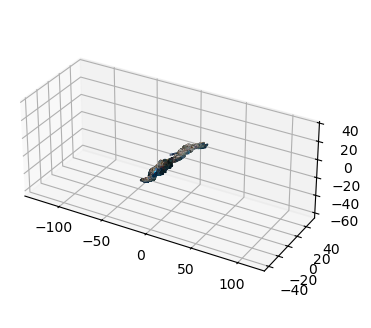

In [5]:
print(pcd)
fig = pcd.plot()

## Scaling the point cloud
To scale the point cloud, load marker coordinates for scalebar targets, define the scalebars, compute the scale factor, and apply it as a 4×4 transform.

In [6]:
# Defining the scalebars
SCALEBAR_SIZES_IN_CM = [["target 31", "target 33", 0.20],  # top-left
                        ["target 35", "target 37", 0.20],  # bot-left
                        ["target 39", "target 41", 0.20],  # top-right
                        ["target 43", "target 45", 0.20]]  # bot-right

# Load the marker coordinates as an Annotations object and then define the scalebars
markers = Annotations("/mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008_markers.csv")
scalebars = Scalebars(SCALEBAR_SIZES_IN_CM, markers)
print(scalebars)

Scalebars(
  num_scalebars=4,
  scalebar_1='target 31'-'target 33' (0.2m) [partial_coords],
  scalebar_2='target 35'-'target 37' (0.2m) [dist=0.1997, residual=-0.0003],
  scalebar_3='target 39'-'target 41' (0.2m) [dist=0.2002, residual=+0.0002],
  scalebar_4='target 43'-'target 45' (0.2m) [dist=0.2000, residual=+0.0000],
  calculated_scalefactor=0.272874,
  variance=0.0000000741,
  std_error=0.0001571586,
  valid_scalebars=3
)


Number of scalebars: 3
Scale factor: 0.27287
Variance: 0.0000000741
Std Error: 0.0001571586


/home/pbongaerts/Github/substrata/src/substrata/annotations.py:1348: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[<Figure size 400x400 with 1 Axes>,
 <Figure size 400x400 with 1 Axes>,
 <Figure size 400x400 with 1 Axes>,
 <Figure size 400x400 with 1 Axes>,
 <Figure size 400x400 with 1 Axes>,
 <Figure size 400x400 with 1 Axes>]

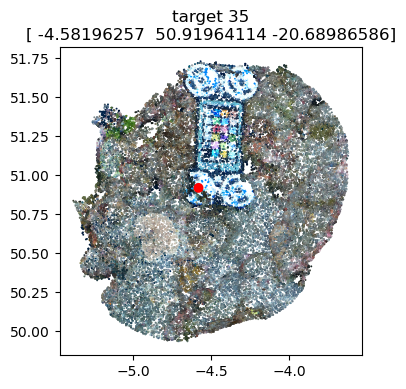

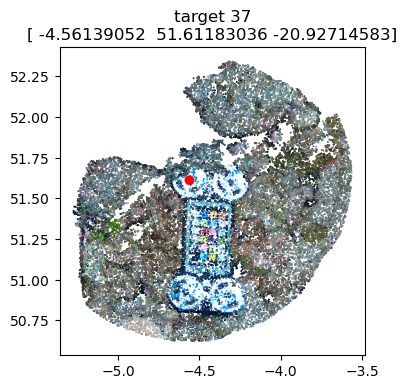

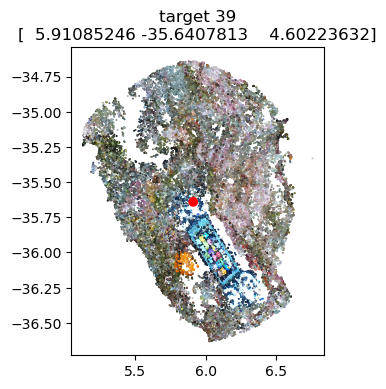

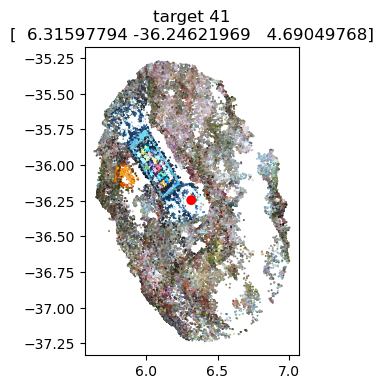

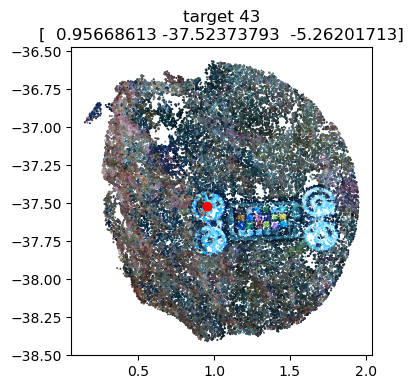

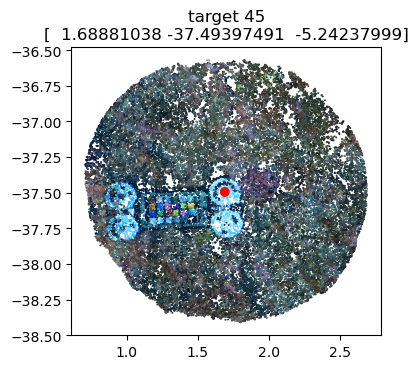

In [7]:
# Optional: Visualize the marker coordinates on the scalebars to ensure accurate positioning
scalebars.show(pcd)                 # needs the pointcloud as argument

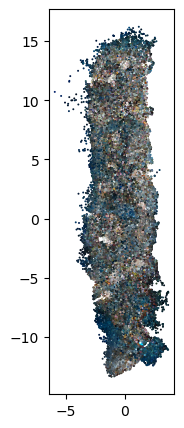

In [8]:
# Apply the scale factor to the pointcloud and visualize to assess
pcd.apply_transform(Transform.from_scale(scalebars.scalefactor))
fig = visualizations.plot_2d(pcd)

## Orientation
Depending on your analysis, it’s often useful to orient the point cloud so depth aligns with the z‑axis. You can either (1) directly specify an up vector, or (2) determine the up vector by regressing camera 3D positions against their known depths.

For the latter, load camera metadata into a `Cameras` object by providing paths to a `.meta.json` file (generated via the Agisoft Metashape API with camera path/center/transform) and a `.cams.xml` file (exported in Agisoft Metashape using `chunk.exportCameras("output_file.cams.xml")`).

In [9]:
cams = Cameras("/mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008.meta.json",
               "/mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008.cams.xml")
print(cams)

Cameras(
  count=1735, sensors=2, enabled=676,
  with_coords=1735, with_datetime=0, with_depth_sensor_m=1059,
  world_transform=identity,
  groups=['auv_PR', 'photos_PGRAM01'],
  groups_counts={'photos_PGRAM01': 676, 'auv_PR': 1059},
  coords_bounds=[min=(-18.006, -48.584, -18.032), max=(13.989, 59.819, 19.135), extent=(31.995, 108.402, 37.167)]
)


If a sufficient number of cameras have measured depth (`depth_sensor_m`, obtained from synchronized sensor data), you can derive the up vector—the 3D direction in the cloud most correlated with depth—and the depth offset (to align the z‑axis approximately with depth) as follows:

Found 442 matching cameras/depths for regression
  Up vector: [0.008332715344911996, 0.06360581525863027, 0.26619189796023607]
  Depth offset: -38.6090 m
  Depth per unit: 0.2738 m
  Mean squared error: 0.0042 m²
  Root mean squared error: 0.0645 m
  Mean absolute error: 0.0524 m
  R²: 0.9983
  Number of matches: 442


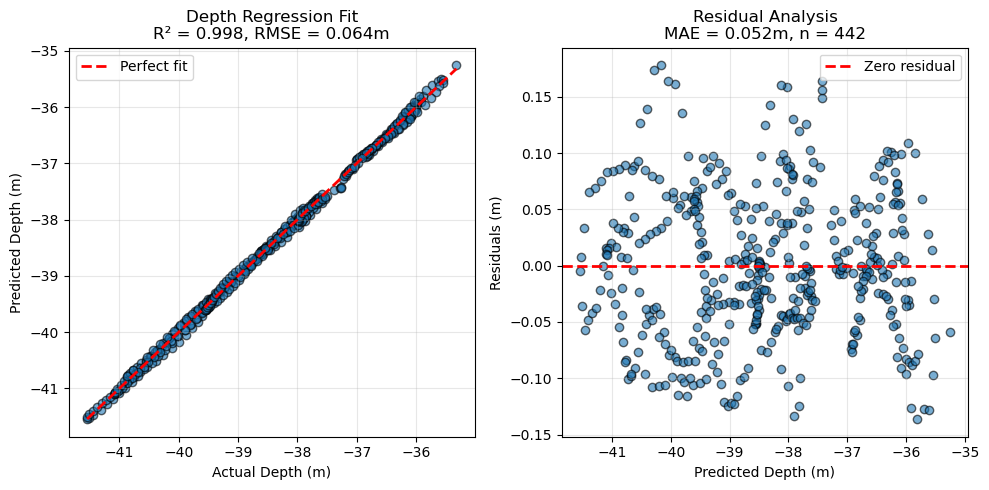

In [10]:
up_vector, depth_offset, depth_per_unit, *_ = (cams.get_up_vector_from_camera_depths(plot=True)
            )

Apply these parameters to orient the point cloud with `pcd.apply_transform(Transform.from_up_vector(up_vector))` followed by `pcd.apply_transform(Transform.from_depth_offset(depth_offset))`. For convenience, `pcd.apply_orientation_transforms` performs scaling, z‑axis alignment, depth offset, and additional transforms (e.g., aligning the widest dimension to the x‑axis and ensuring +y is upslope).

Afterward, plot the different views as a quick check that scaling/orientation were applied correctly.

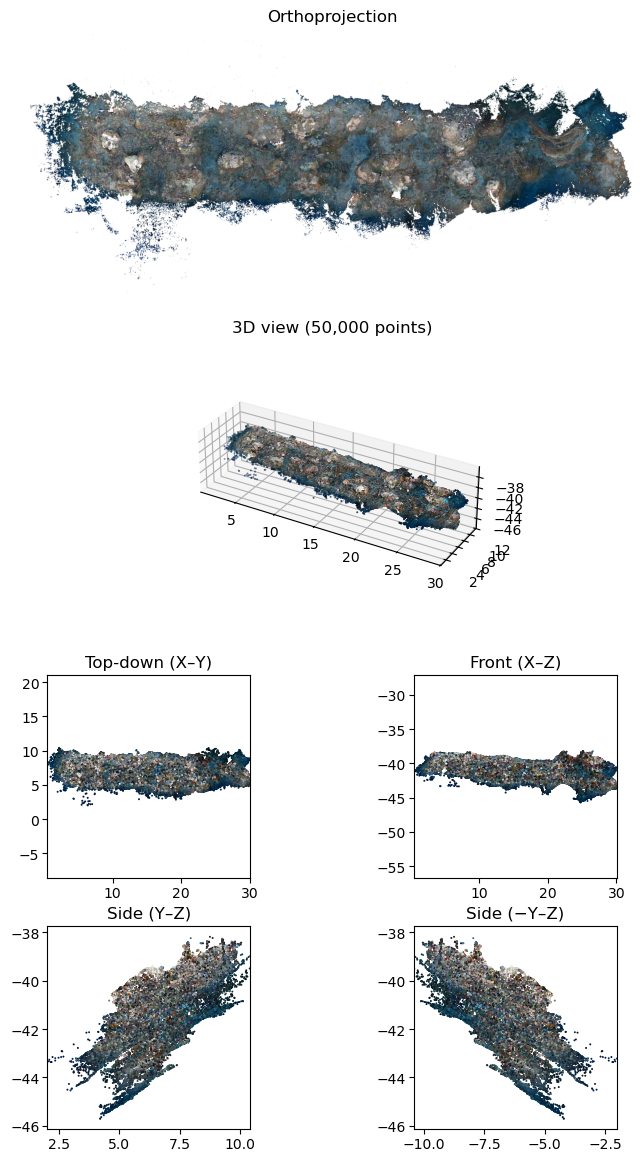

In [11]:
pcd.apply_orientation_transforms(scale_factor=1.0,                      # skipping scale as already applied in this case
                                 up_vector=up_vector, 
                                 depth_offset=depth_offset, 
                                 depth_scale_factor=depth_per_unit)
fig = pcd.plot_views()
           

The transform used for orientation should also be applied to any other objects used with the point cloud (e.g., `Cameras`, `Annotations`). Apply the cumulative `world_transform` using the generic `apply_transform` method.

In [12]:
print(pcd)
cams.apply_transform(pcd.world_transform)
print('Camera world_transform:\n', cams.world_transform)

PointCloud(name='ton_tof_40m_20241008', path='/mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008_dec50M.ply')
- points: 50,000,000
- colors: yes
- normals: yes
- bounding_box: [min=(0.000, 0.000, -46.147), max=(30.331, 13.227, -37.099), extent=(30.331, 13.227, 9.048)]
- world_transform: non-identity
- world_transform_matrix:
   0.014947 -0.265110  0.062879  17.627868
   0.272338  0.012618 -0.011540  6.871499
   0.008304  0.063388  0.265280 -38.608986
   0.000000  0.000000  0.000000  1.000000
- transforms_applied: 7
Camera world_transform:
 [[ 1.49472062e-02 -2.65109654e-01  6.28793175e-02  1.76278683e+01]
 [ 2.72337985e-01  1.26176500e-02 -1.15400613e-02  6.87149939e+00]
 [ 8.30416371e-03  6.33878731e-02  2.65279805e-01 -3.86089862e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


You can visualize camera positions within the point cloud:

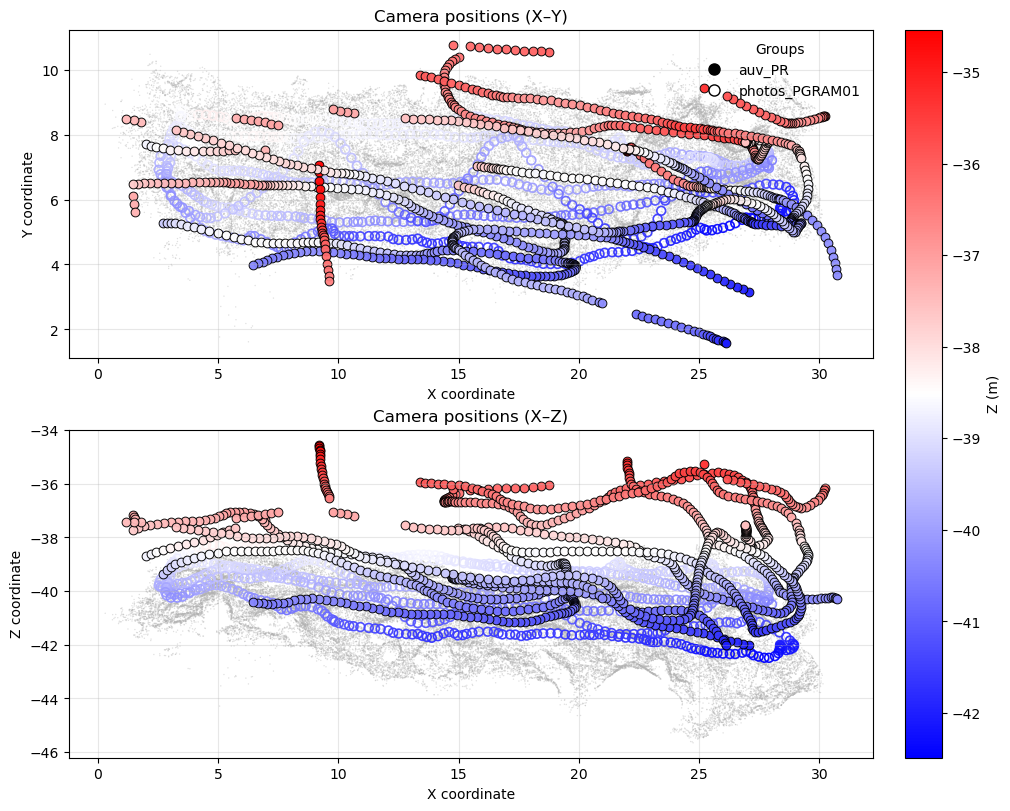

In [13]:
cams.show(pcd)

Plot camera depth residuals (for cameras with `depth_sensor_m`) to check for bias:

(<Figure size 1500x500 with 2 Axes>, <Figure size 1500x500 with 3 Axes>)

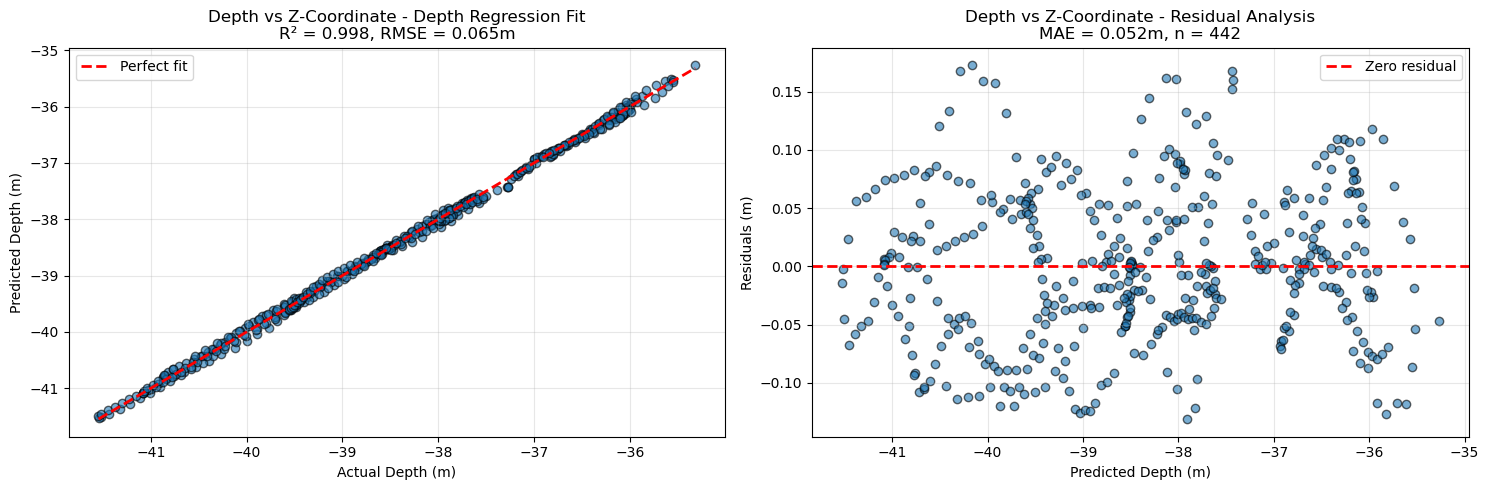

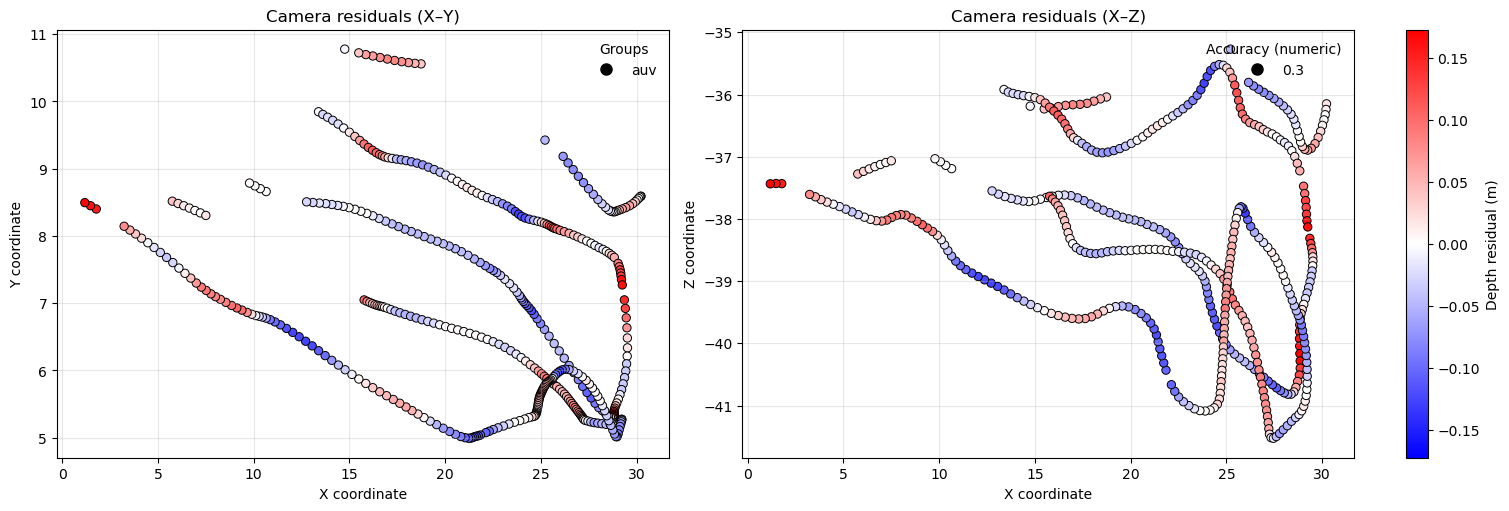

In [14]:

cams.show_z_vs_depth_residuals()

 Often `scale_factor` and `depth_per_unit` (scaling along the z‑axis) differ slightly. Applying a global `scale_factor` therefore makes z values only an approximate depth. For absolute depth at a camera, use the `depth_in_m` property. After assigning `up_vector` and `depth_offset` to `Cameras`, you can also plot residuals versus estimated absolute depth.

(<Figure size 1500x500 with 2 Axes>, <Figure size 1500x500 with 3 Axes>)

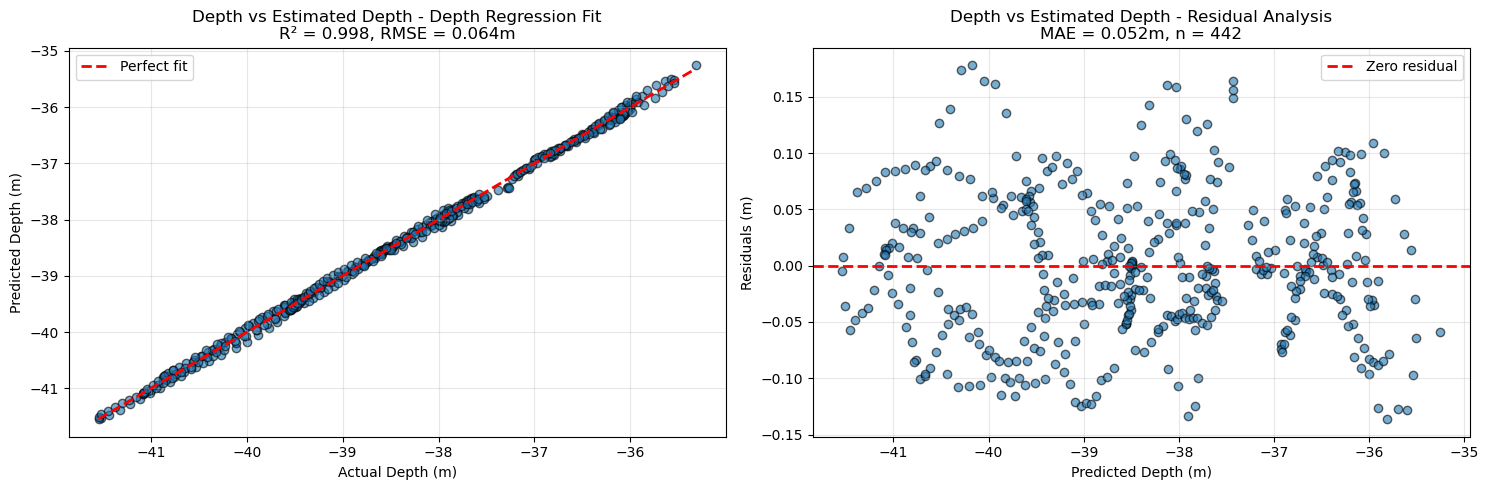

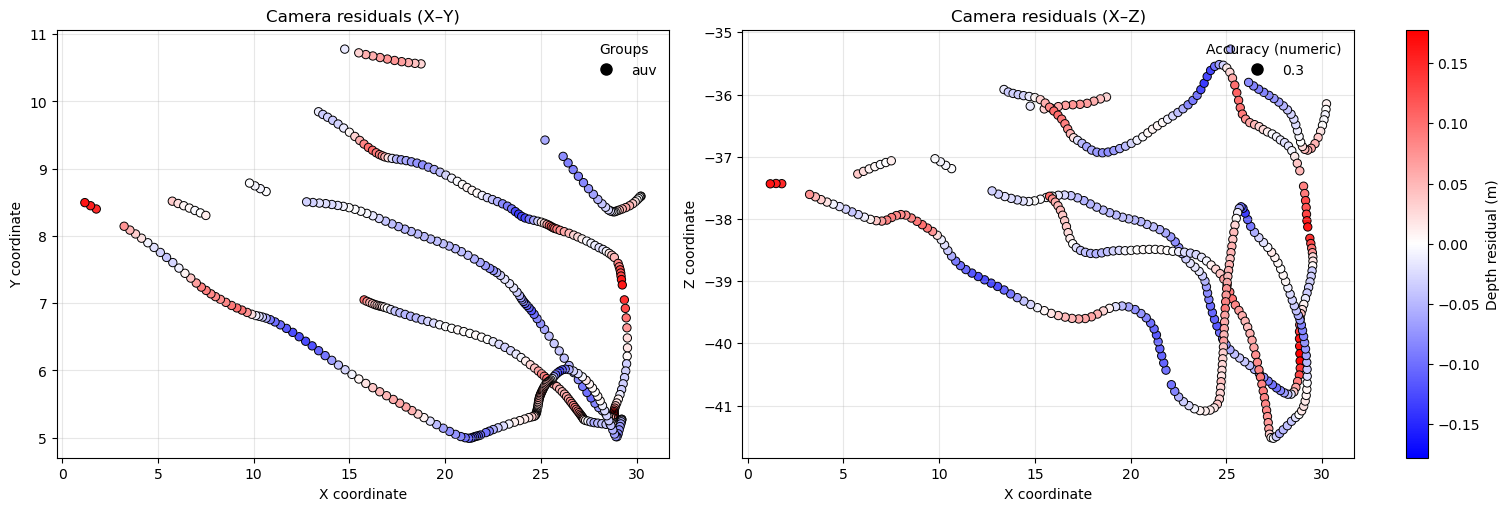

In [15]:
cams.depth_offset, cams.up_vector, cams.depth_per_unit = depth_offset, up_vector, depth_per_unit
cams.show_depth_vs_est_depth_residuals()